In [1]:
import numpy as np
import h5py
import random

from learner_models import OrigUNet

import torch
import torch.nn.functional as F

import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [59]:
h5_path = "../../../data/real_0.h5"
!file $h5_path

../../../data/real_0.h5: Hierarchical Data Format (version 5) data


In [60]:
weights_path = "../../../models/pretrained_evfly/real_forest_Dtheta.pth"

In [61]:
model = OrigUNet(num_in_channels=1, num_out_channels=1, num_recurrent=[1, 0], enc_params=None, dec_params=None, input_shape=[1, 1, 260, 346], device=device, logger=print, velpred=0, fc_params=None, form_BEV=2, is_deployment=False, is_large=False, evs_min_cutoff=0, skip_type="interp")
model = model.to(device)

[OrigUNet] Initializing OrigUNet with num_in_channels=1, num_out_channels=1, num_recurrent=[1, 0], form_BEV=2, is_deployment=False, evs_min_cutoff=0, skip_type=interp
[OrigUNet] Using 1 recurrent layers


In [62]:
state_dict = torch.load(weights_path, map_location=device, weights_only=True)
model.load_state_dict(state_dict)
model.eval()

OrigUNet(
  (unet_e11): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (unet_e12): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
  (unet_pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (unet_e21): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (unet_e22): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
  (unet_pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (unet_e31): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (unet_e32): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1))
  (unet_pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (unet_e41): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1))
  (unet_e42): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
  (unet_pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (unet_e51): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1))
  (unet_e52): Conv2d(512, 512, kernel_size

In [63]:
def enumerate_trajectories(path, shuffle=True):
    with h5py.File(path, "r") as f:
        traj_ids = list(f.keys())
        if shuffle:
            random.shuffle(traj_ids)

        for traj_id in traj_ids:
            traj = f[traj_id]
            yield traj["trajlength"][()] - 1, traj["depths"][1:], traj["evs"][:]

In [64]:
enumerate_frames = lambda traj: ((depth, ev) for depth, ev in zip(*traj[1:]))

In [65]:
trajectories = enumerate_trajectories(h5_path)

In [66]:
trajectory = next(trajectories)

In [67]:
def calculate_loss(gt, pred, eps=1e-8):
    mask = gt > 0

    valid_gt = gt[mask]
    valid_pred = pred[mask]

    pixel_loss = ((valid_gt - valid_pred) ** 2) / (valid_gt + eps)
    return pixel_loss.mean()

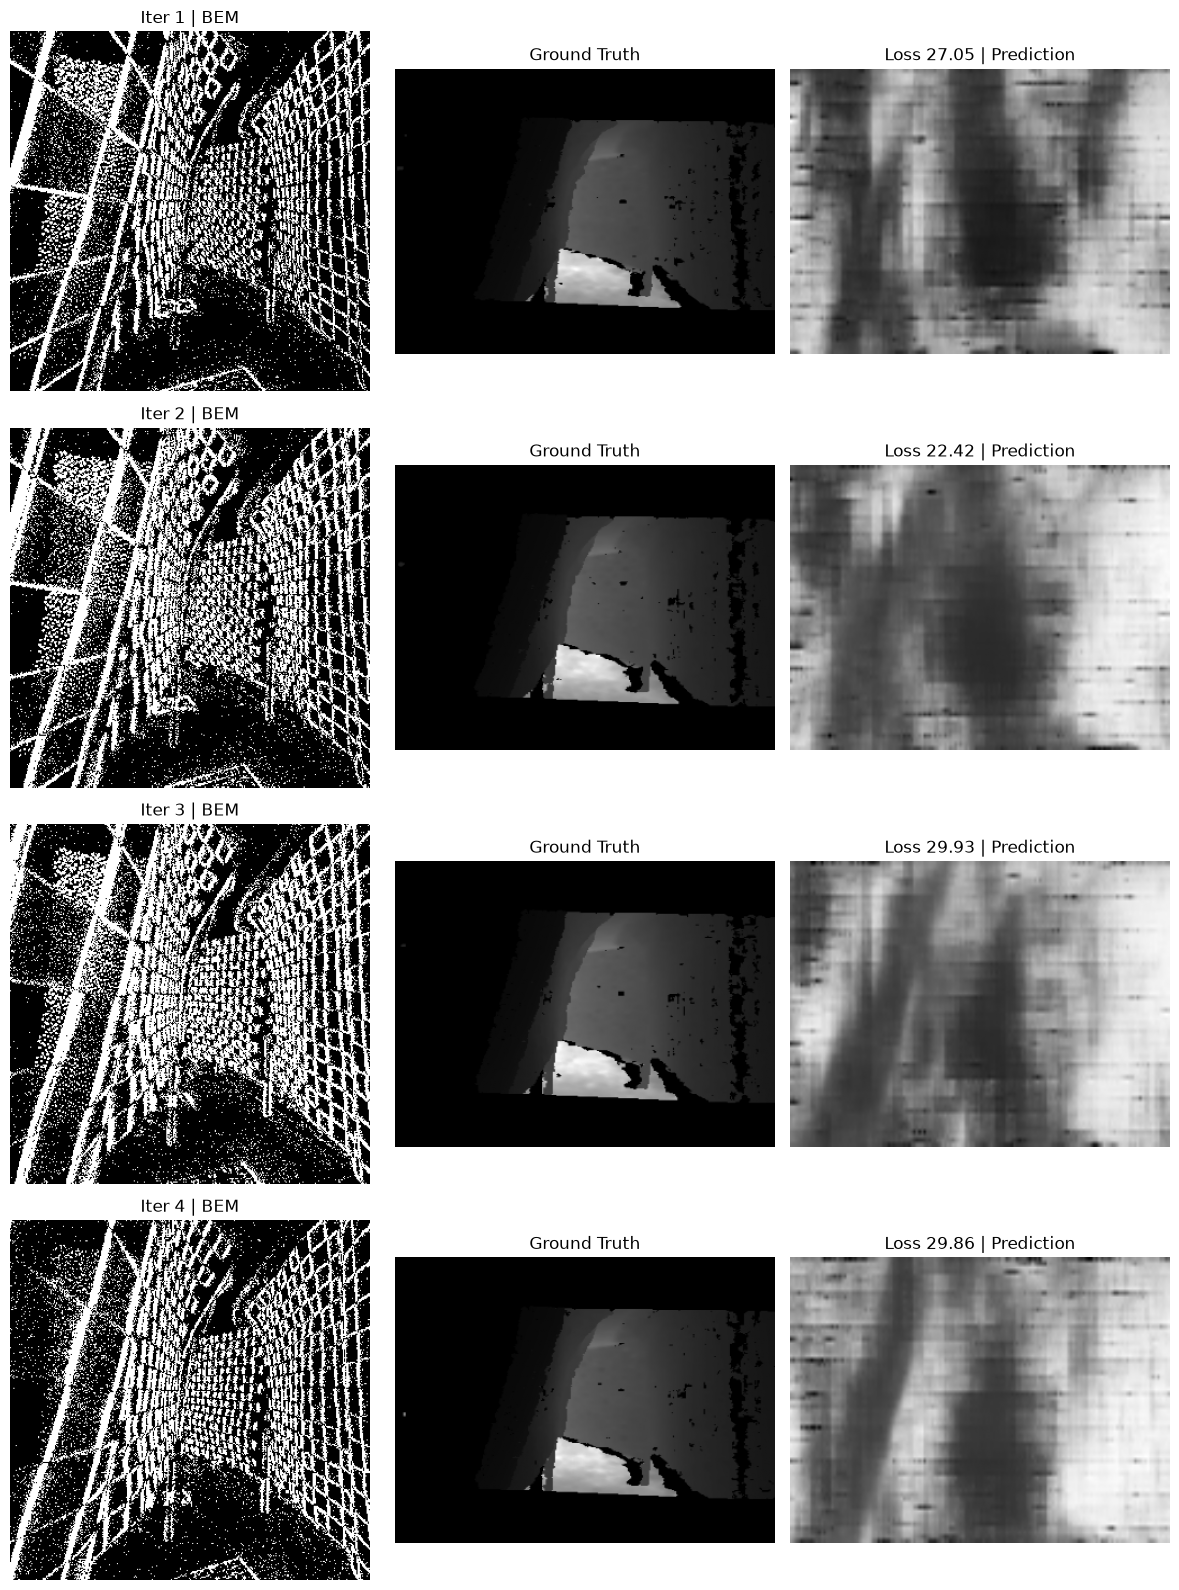

In [72]:
with torch.no_grad():
    h = None

    prep_image = lambda im: torch.from_numpy(im).to(device).unsqueeze(0).unsqueeze(0)
    unprep_image = lambda im: im.squeeze().squeeze().cpu().numpy()

    visualization_history = []

    freq = (trajectory[0] // 10) + 1
    
    for i, (depth, ev) in enumerate(enumerate_frames(trajectory)):
        depth_prep = prep_image(depth)
        ev_prep = prep_image(ev)

        
        depth_prep = F.interpolate(depth_prep, size=(260, 346), mode='bilinear', align_corners=False)
        ev_prep = F.interpolate(ev_prep, size=(260, 346), mode='bilinear', align_corners=False)
        
        _, (depth_pred, _, h) = model([ev_prep, None, h])

        if i % freq == 0:    
            visualization_history.append({
                "bem": (ev != 0).astype(int),
                "pred": unprep_image(depth_pred),
                "truth": unprep_image(depth_prep),
                "loss": calculate_loss(depth_prep, depth_pred),
                "iter": i + 1
            })

    num_rows = len(visualization_history)

    fig, axes = plt.subplots(num_rows, 3, figsize=(12, 4 * num_rows))
    
    if num_rows == 1:
        axes = [axes]
    
    for i, data in enumerate(visualization_history):
        ax_bem = axes[i][0]
        ax_pred = axes[i][2]
        ax_true = axes[i][1]

        im0 = ax_bem.imshow(data["bem"], cmap="gray")
        ax_bem.set_title(f"Iter {data["iter"]} | BEM")
        ax_bem.axis("off")
        
        im1 = ax_pred.imshow(data["pred"], cmap="gray")
        ax_pred.set_title(f"Loss {data["loss"]:.2f} | Prediction")
        ax_pred.axis("off")
        
        im2 = ax_true.imshow(data["truth"], cmap="gray")
        ax_true.set_title(f"Ground Truth")
        ax_true.axis("off")
    
    plt.tight_layout()
    plt.show()